# Credit Risk Scoring ML Project

This notebook predicts whether a loan applicant will default (`1`) or not default (`0`) using Kaggle's **Give Me Some Credit** dataset (`cs-training.csv`). It covers exploration, cleaning, feature engineering, imbalance handling, model comparison, tuning, explainability, artifact saving, and a FastAPI scoring endpoint.

## 1. IMPORTS & SETUP

This section installs and imports all required libraries, sets the seaborn style, suppresses warnings, and fixes random seeds for reproducible results.

In [1]:
# Install required packages into the active Jupyter kernel.
%pip install -q pandas numpy matplotlib seaborn scikit-learn xgboost imbalanced-learn shap joblib fastapi uvicorn

# Core utilities
import os
import random
import warnings
from pathlib import Path

# Data and plotting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling and evaluation
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, f1_score, classification_report, confusion_matrix,
    roc_curve, precision_recall_curve, average_precision_score
)
from imblearn.combine import SMOTEENN
from xgboost import XGBClassifier

# Explainability, persistence, and API imports
import shap
import joblib
from fastapi import FastAPI
import uvicorn

# Global settings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
plt.rcParams['figure.figsize'] = (10, 6)

# Project paths
DATA_PATH = Path('cs-training.csv')
MODEL_PATH = Path('credit_risk_model.pkl')
SCALER_PATH = Path('credit_scaler.pkl')
FEATURE_NAMES_PATH = Path('feature_names.txt')
TARGET = 'SeriousDlqin2yrs'

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


C:\Users\Ashish\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. LOAD & EXPLORE DATA

Here we load the CSV, inspect shape, dtypes, first rows, missingness, and target imbalance. The charts give a quick view of class distribution and numeric relationships.

Shape: (150000, 12)


,dtype
Unnamed: 0,int64
SeriousDlqin2yrs,int64
RevolvingUtilizationOfUnsecuredLines,float64
age,int64
NumberOfTime30-59DaysPastDueNotWorse,int64
DebtRatio,float64
MonthlyIncome,float64
NumberOfOpenCreditLinesAndLoans,int64
NumberOfTimes90DaysLate,int64
NumberRealEstateLoansOrLines,int64


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


,missing_count,missing_percent
MonthlyIncome,29731,19.82
NumberOfDependents,3924,2.62
Unnamed: 0,0,0.00
SeriousDlqin2yrs,0,0.00
age,0,0.00
RevolvingUtilizationOfUnsecuredLines,0,0.00
DebtRatio,0,0.00
NumberOfTime30-59DaysPastDueNotWorse,0,0.00
NumberOfOpenCreditLinesAndLoans,0,0.00
NumberOfTimes90DaysLate,0,0.00


,count,percent
SeriousDlqin2yrs,,
0,139974,93.32
1,10026,6.68


Default class rate: 6.68%


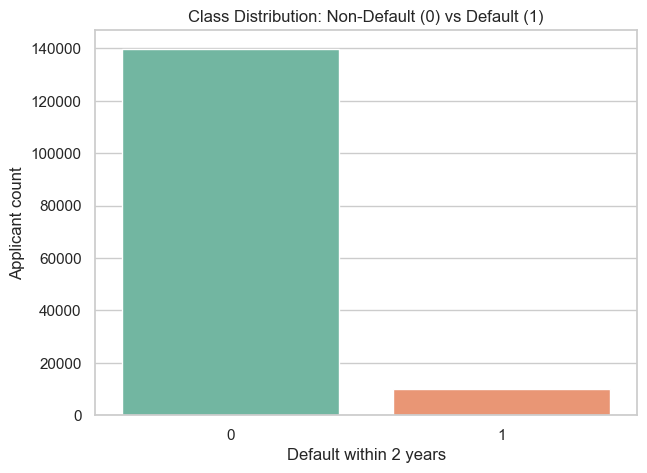

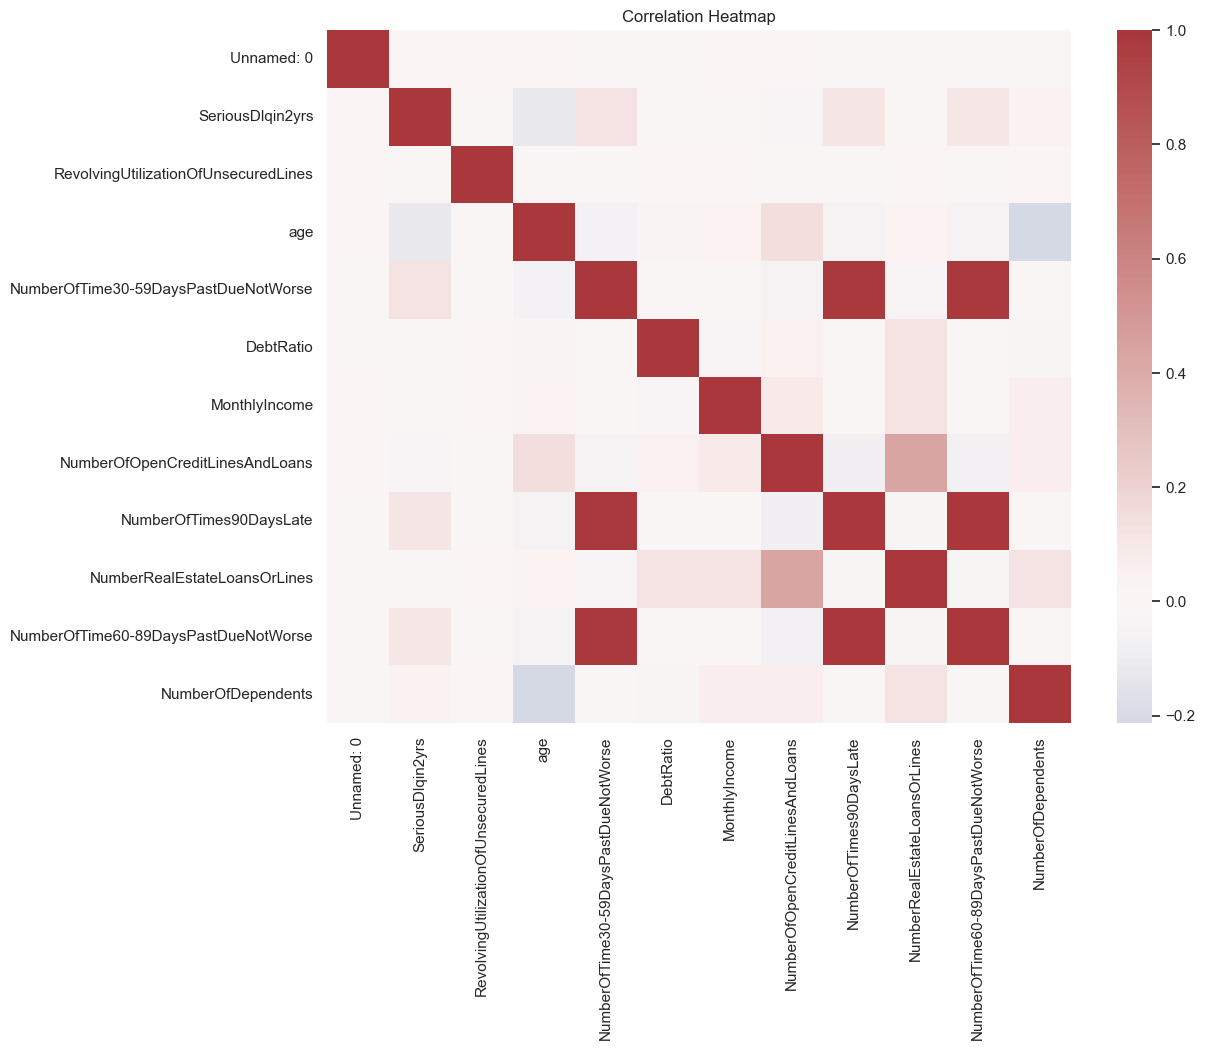

In [2]:
# Load the Kaggle Give Me Some Credit training dataset.
# Place cs-training.csv beside this notebook before running all cells.
if not DATA_PATH.exists():
    raise FileNotFoundError('cs-training.csv was not found. Download it from Kaggle and place it beside this notebook.')

raw_df = pd.read_csv(DATA_PATH)
df = raw_df.copy()

# Show shape, dtypes, and first five rows.
print('Shape:', df.shape)
display(df.dtypes.to_frame('dtype'))
display(df.head())

# Show missing value counts and percentages.
missing_summary = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_percent': (df.isna().mean() * 100).round(2)
}).sort_values('missing_percent', ascending=False)
display(missing_summary)

# Show class distribution and imbalance.
class_summary = pd.DataFrame({
    'count': df[TARGET].value_counts().sort_index(),
    'percent': (df[TARGET].value_counts(normalize=True).sort_index() * 100).round(2)
})
display(class_summary)
print(f"Default class rate: {class_summary.loc[1, 'percent']:.2f}%" if 1 in class_summary.index else 'No default class found.')

# Plot class distribution bar chart.
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x=TARGET, palette='Set2')
plt.title('Class Distribution: Non-Default (0) vs Default (1)')
plt.xlabel('Default within 2 years')
plt.ylabel('Applicant count')
plt.show()

# Plot correlation heatmap for numeric columns.
plt.figure(figsize=(12, 9))
sns.heatmap(df.select_dtypes(include=np.number).corr(), cmap='vlag', center=0, annot=False)
plt.title('Correlation Heatmap')
plt.show()

## 3. DATA CLEANING

This section drops the unnamed index column, replaces requested sentinel values with missing values, imputes missing income and dependents, removes unrealistic ages, and caps major outliers using the IQR method.

In [3]:
# Copy explored data for cleaning.
df_clean = df.copy()

# Drop the unnamed index column from Kaggle's CSV export.
unnamed_cols = [col for col in df_clean.columns if col.lower().startswith('unnamed')]
df_clean = df_clean.drop(columns=unnamed_cols, errors='ignore')

# Replace sentinel values with NaN in feature columns only.
feature_cols_for_sentinel = [col for col in df_clean.columns if col != TARGET]
df_clean[feature_cols_for_sentinel] = df_clean[feature_cols_for_sentinel].replace([98, 99, 999], np.nan)

# Fill MonthlyIncome with median grouped by NumberOfDependents.
if 'NumberOfDependents' in df_clean.columns and 'MonthlyIncome' in df_clean.columns:
    temp_dependents = df_clean['NumberOfDependents'].fillna(df_clean['NumberOfDependents'].median())
    grouped_income_median = df_clean.groupby(temp_dependents)['MonthlyIncome'].transform('median')
    df_clean['MonthlyIncome'] = df_clean['MonthlyIncome'].fillna(grouped_income_median).fillna(df_clean['MonthlyIncome'].median())

# Fill missing NumberOfDependents with median.
if 'NumberOfDependents' in df_clean.columns:
    df_clean['NumberOfDependents'] = df_clean['NumberOfDependents'].fillna(df_clean['NumberOfDependents'].median())

# Fill any remaining numeric feature missing values created by sentinel replacement.
numeric_feature_cols = [col for col in df_clean.select_dtypes(include=np.number).columns if col != TARGET]
for numeric_col in numeric_feature_cols:
    df_clean[numeric_col] = df_clean[numeric_col].fillna(df_clean[numeric_col].median())

# Remove rows with unrealistic ages (column name is 'age' in this dataset).
age_col = 'age' if 'age' in df_clean.columns else 'Age' if 'Age' in df_clean.columns else None
if age_col:
    before_age = len(df_clean)
    df_clean = df_clean[(df_clean[age_col] >= 18) & (df_clean[age_col] <= 100)].copy()
    print(f'Removed {before_age - len(df_clean)} rows with age < 18 or age > 100')

# Cap outliers using IQR on selected skewed columns.
def cap_outliers_iqr(dataframe, column):
    q1 = dataframe[column].quantile(0.25)
    q3 = dataframe[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    dataframe[column] = dataframe[column].clip(lower=lower_bound, upper=upper_bound)
    return dataframe

for outlier_col in ['DebtRatio', 'MonthlyIncome', 'RevolvingUtilizationOfUnsecuredLines']:
    if outlier_col in df_clean.columns:
        df_clean = cap_outliers_iqr(df_clean, outlier_col)

# Confirm cleaning output.
print('Cleaned shape:', df_clean.shape)
display(df_clean.isna().sum().to_frame('remaining_missing_values'))
display(df_clean.head())

Removed 14 rows with age < 18 or age > 100
Cleaned shape: (149986, 11)


,remaining_missing_values
SeriousDlqin2yrs,0
RevolvingUtilizationOfUnsecuredLines,0
age,0
NumberOfTime30-59DaysPastDueNotWorse,0
DebtRatio,0
MonthlyIncome,0
NumberOfOpenCreditLinesAndLoans,0
NumberOfTimes90DaysLate,0
NumberRealEstateLoansOrLines,0
NumberOfTime60-89DaysPastDueNotWorse,0


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45.0,2.0,0.802982,9120.0,13,0.0,6,0.0,2.0
1,0,0.957151,40.0,0.0,0.121876,2600.0,4,0.0,0,0.0,1.0
2,0,0.658180,38.0,1.0,0.085113,3042.0,2,1.0,0,0.0,0.0
3,0,0.233810,30.0,0.0,0.036050,3300.0,5,0.0,0,0.0,0.0
4,0,0.907239,49.0,1.0,0.024926,12644.0,7,0.0,1,0.0,0.0


## 4. FEATURE ENGINEERING

We create affordability, delinquency, utilization, and household-income features that can make default-risk patterns easier for the models to learn.

In [4]:
# Copy cleaned data before creating engineered features.
df_fe = df_clean.copy()

# Approximate debt exposure from debt ratio and income.
df_fe['DebtToIncomeRatio'] = df_fe['DebtRatio'] * df_fe['MonthlyIncome']

# Combine late-payment buckets into one delinquency summary.
df_fe['TotalLatePayments'] = (
    df_fe['NumberOfTime30-59DaysPastDueNotWorse']
    + df_fe['NumberOfTime60-89DaysPastDueNotWorse']
    + df_fe['NumberOfTimes90DaysLate']
)

# Flag applicants using more than 100% of unsecured revolving credit.
df_fe['CreditUtilizationFlag'] = (df_fe['RevolvingUtilizationOfUnsecuredLines'] > 1).astype(int)

# Normalize income by dependency burden.
df_fe['IncomePerDependent'] = df_fe['MonthlyIncome'] / (df_fe['NumberOfDependents'] + 1)

# Display engineered feature preview.
engineered_columns = ['DebtToIncomeRatio', 'TotalLatePayments', 'CreditUtilizationFlag', 'IncomePerDependent']
display(df_fe[engineered_columns].head())
print('Feature-engineered shape:', df_fe.shape)

,DebtToIncomeRatio,TotalLatePayments,CreditUtilizationFlag,IncomePerDependent
0,7323.197016,2.0,0,3040.0
1,316.878123,0.0,0,1300.0
2,258.914887,2.0,0,3042.0
3,118.963951,0.0,0,3300.0
4,315.160488,1.0,0,12644.0


Feature-engineered shape: (149986, 15)


## 5. TRAIN/TEST SPLIT & SCALING

This section creates an 80/20 stratified train-test split and scales all numeric features. The scaler is fit on training data only to avoid leakage.

In [5]:
# Separate features and target.
X = df_fe.drop(columns=[TARGET])
y = df_fe[TARGET].astype(int)
feature_names = X.columns.tolist()

# Print class counts before splitting.
print('Class counts before split:')
print(y.value_counts().sort_index())

# Stratified 80/20 split.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

# Scale numeric features using training statistics only.
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_names, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_names, index=X_test.index)

# Print class counts after splitting.
print('\nTraining class counts:')
print(y_train.value_counts().sort_index())
print('\nTest class counts:')
print(y_test.value_counts().sort_index())

Class counts before split:
SeriousDlqin2yrs
0    139961
1     10025
Name: count, dtype: int64



Training class counts:
SeriousDlqin2yrs
0    111968
1      8020
Name: count, dtype: int64

Test class counts:
SeriousDlqin2yrs
0    27993
1     2005
Name: count, dtype: int64


## 6. HANDLE CLASS IMBALANCE

Defaults are the minority class, so we apply `SMOTEENN` to the training set only. This improves minority-class learning while keeping the test set untouched for honest evaluation.

In [6]:
# Show training class distribution before resampling.
print('Before SMOTEENN:')
print(y_train.value_counts().sort_index())

# Apply SMOTEENN only to the training data.
smote_enn = SMOTEENN(random_state=RANDOM_STATE)
X_train_resampled_array, y_train_resampled = smote_enn.fit_resample(X_train_scaled, y_train)
X_train_resampled = pd.DataFrame(X_train_resampled_array, columns=feature_names)
y_train_resampled = pd.Series(y_train_resampled, name=TARGET)

# Show training class distribution after resampling.
print('\nAfter SMOTEENN:')
print(y_train_resampled.value_counts().sort_index())

Before SMOTEENN:
SeriousDlqin2yrs
0    111968
1      8020
Name: count, dtype: int64



After SMOTEENN:
SeriousDlqin2yrs
0     87887
1    105052
Name: count, dtype: int64


## 7. TRAIN 3 MODELS & COMPARE

We train Logistic Regression, Random Forest, and XGBoost. Each model is evaluated with AUC-ROC and F1 for the default class, plus a classification report and confusion-matrix heatmap.


Logistic Regression
-------------------
AUC-ROC: 0.8656
F1 score for class 1/default: 0.3262

Classification report:
                 precision    recall  f1-score   support

Non-default (0)       0.98      0.78      0.87     27993
    Default (1)       0.20      0.80      0.33      2005

       accuracy                           0.78     29998
      macro avg       0.59      0.79      0.60     29998
   weighted avg       0.93      0.78      0.83     29998



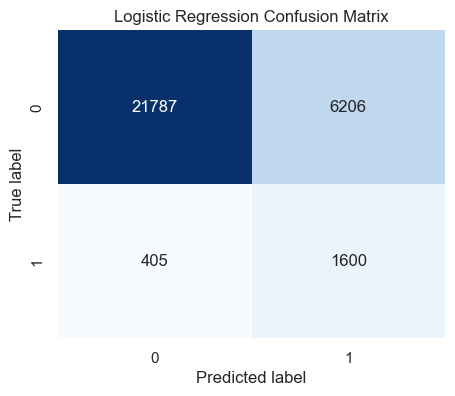


Random Forest
-------------
AUC-ROC: 0.8469
F1 score for class 1/default: 0.3931

Classification report:
                 precision    recall  f1-score   support

Non-default (0)       0.97      0.89      0.93     27993
    Default (1)       0.28      0.64      0.39      2005

       accuracy                           0.87     29998
      macro avg       0.63      0.76      0.66     29998
   weighted avg       0.93      0.87      0.89     29998



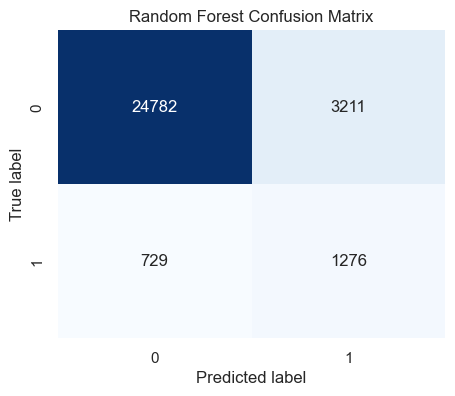


XGBoost
-------
AUC-ROC: 0.8671
F1 score for class 1/default: 0.1672

Classification report:
                 precision    recall  f1-score   support

Non-default (0)       0.99      0.31      0.47     27993
    Default (1)       0.09      0.97      0.17      2005

       accuracy                           0.35     29998
      macro avg       0.54      0.64      0.32     29998
   weighted avg       0.93      0.35      0.45     29998



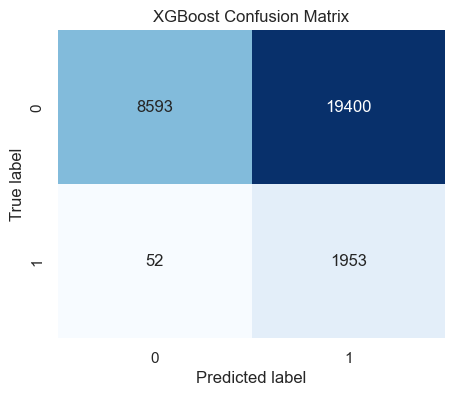

,model,auc_roc,f1_default
2,XGBoost,0.867106,0.167223
0,Logistic Regression,0.865629,0.326165
1,Random Forest,0.846857,0.393099


In [7]:
# Define a reusable evaluation helper for all models.
def evaluate_model(model_name, model, X_eval, y_eval):
    y_pred = model.predict(X_eval)
    y_proba = model.predict_proba(X_eval)[:, 1]
    auc = roc_auc_score(y_eval, y_proba)
    f1_default = f1_score(y_eval, y_pred, pos_label=1)
    print(f'\n{model_name}')
    print('-' * len(model_name))
    print(f'AUC-ROC: {auc:.4f}')
    print(f'F1 score for class 1/default: {f1_default:.4f}')
    print('\nClassification report:')
    print(classification_report(y_eval, y_pred, target_names=['Non-default (0)', 'Default (1)']))
    cm = confusion_matrix(y_eval, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.show()
    return {'model_name': model_name, 'model': model, 'auc_roc': auc, 'f1_default': f1_default}

# Compute XGBoost class weight ratio from the original training split.
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()
scale_pos_weight = negative_count / positive_count

# Create requested models.
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost': XGBClassifier(
        n_estimators=100, max_depth=3, learning_rate=0.1,
        objective='binary:logistic', eval_metric='logloss',
        scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE, n_jobs=-1
    ),
}

# Train models on resampled data and evaluate on the untouched test set.
comparison_results = []
for model_name, model in models.items():
    model.fit(X_train_resampled, y_train_resampled)
    comparison_results.append(evaluate_model(model_name, model, X_test_scaled, y_test))

# Compare model metrics in a table.
comparison_df = pd.DataFrame([
    {'model': r['model_name'], 'auc_roc': r['auc_roc'], 'f1_default': r['f1_default']}
    for r in comparison_results
]).sort_values('auc_roc', ascending=False)
display(comparison_df)

## 8. HYPERPARAMETER TUNING

We tune XGBoost using `GridSearchCV` with the requested parameter grid, 5-fold cross-validation, and AUC-ROC scoring.

In [8]:
# Define the base XGBoost model and requested parameter grid.
xgb_base = XGBClassifier(
    objective='binary:logistic', eval_metric='logloss',
    scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE, n_jobs=-1
)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1],
}

# Run 5-fold grid search using AUC-ROC.
grid_search = GridSearchCV(
    estimator=xgb_base, param_grid=param_grid,
    cv=5, scoring='roc_auc', n_jobs=-1, verbose=1
)
grid_search.fit(X_train_resampled, y_train_resampled)

# Store and print best model details.
best_model = grid_search.best_estimator_
print('Best parameters:', grid_search.best_params_)
print(f'Best cross-validated AUC-ROC: {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 12 candidates, totalling 60 fits


Best parameters: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}
Best cross-validated AUC-ROC: 0.9900


## 9. EVALUATE BEST MODEL

The tuned XGBoost model is evaluated on the holdout test set with ROC, Precision-Recall, classification report, and confusion matrix.

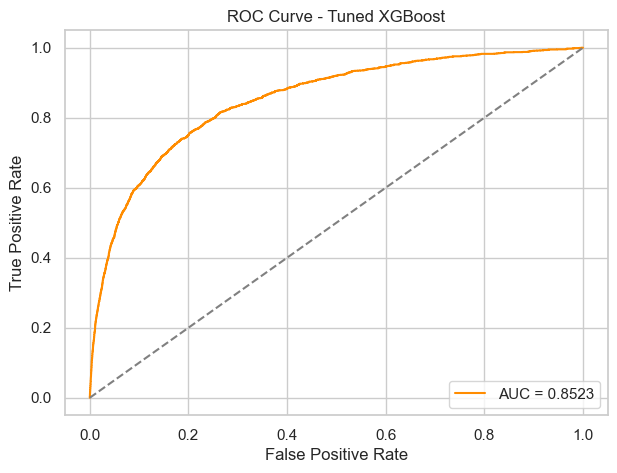

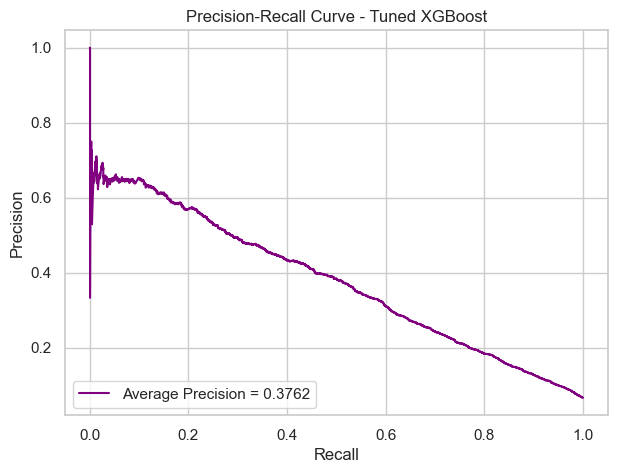

Final classification report:
                 precision    recall  f1-score   support

Non-default (0)       0.98      0.66      0.79     27993
    Default (1)       0.15      0.86      0.26      2005

       accuracy                           0.67     29998
      macro avg       0.57      0.76      0.52     29998
   weighted avg       0.93      0.67      0.75     29998



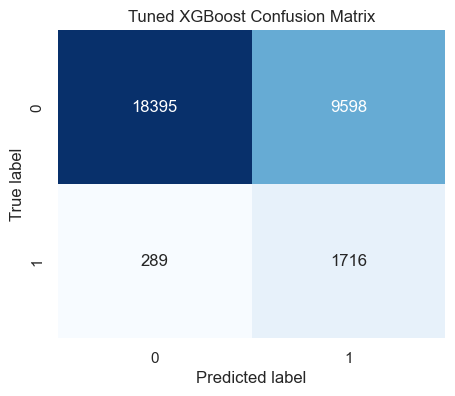

In [9]:
# Predict classes and probabilities on test data.
y_test_pred = best_model.predict(X_test_scaled)
y_test_proba = best_model.predict_proba(X_test_scaled)[:, 1]

# Plot ROC curve with AUC label.
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
final_auc = roc_auc_score(y_test, y_test_proba)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'AUC = {final_auc:.4f}', color='darkorange')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('ROC Curve - Tuned XGBoost')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

# Plot Precision-Recall curve.
precision, recall, _ = precision_recall_curve(y_test, y_test_proba)
avg_precision = average_precision_score(y_test, y_test_proba)
plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f'Average Precision = {avg_precision:.4f}', color='purple')
plt.title('Precision-Recall Curve - Tuned XGBoost')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='lower left')
plt.show()

# Print final report and show confusion matrix.
print('Final classification report:')
print(classification_report(y_test, y_test_pred, target_names=['Non-default (0)', 'Default (1)']))

final_cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(final_cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Tuned XGBoost Confusion Matrix')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()

## 10. SHAP EXPLAINABILITY

SHAP explains which features most influence the tuned XGBoost model globally and for individual predictions. We compute SHAP values on `X_test`, show bar and beeswarm summary plots, display force plots, and print the top five features.

SHAP Summary Plot (Bar):


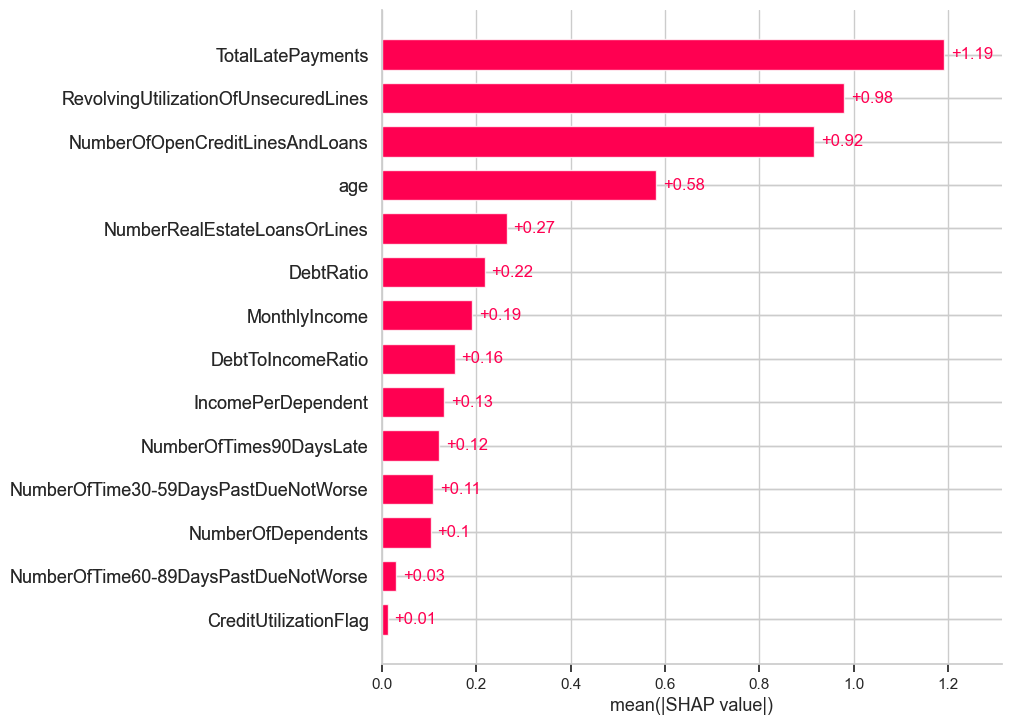

SHAP Summary Plot (Beeswarm):


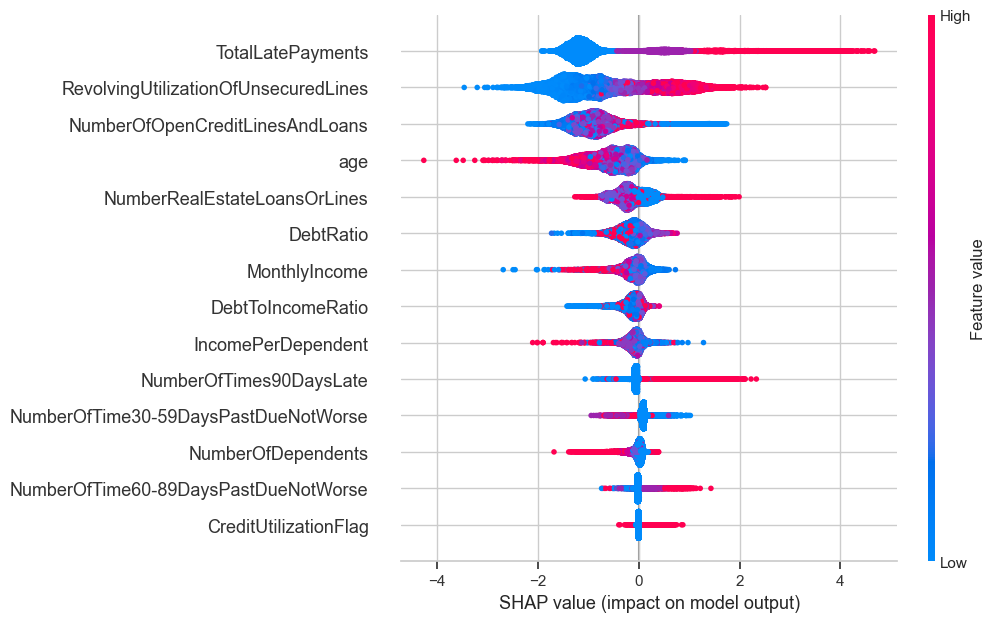


Waterfall plot for test observation 0


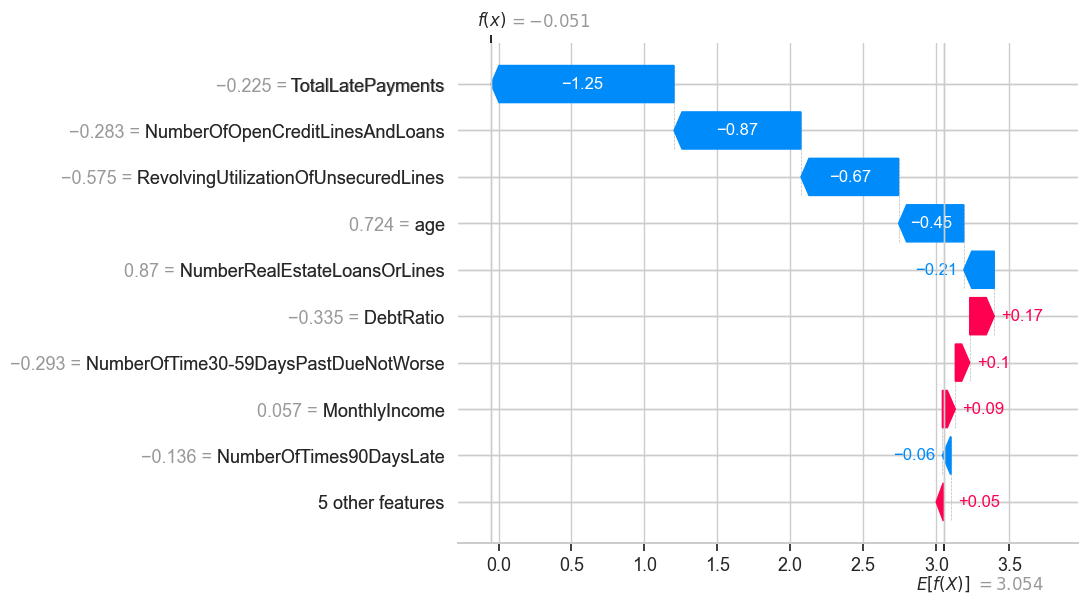


Waterfall plot for test observation 1


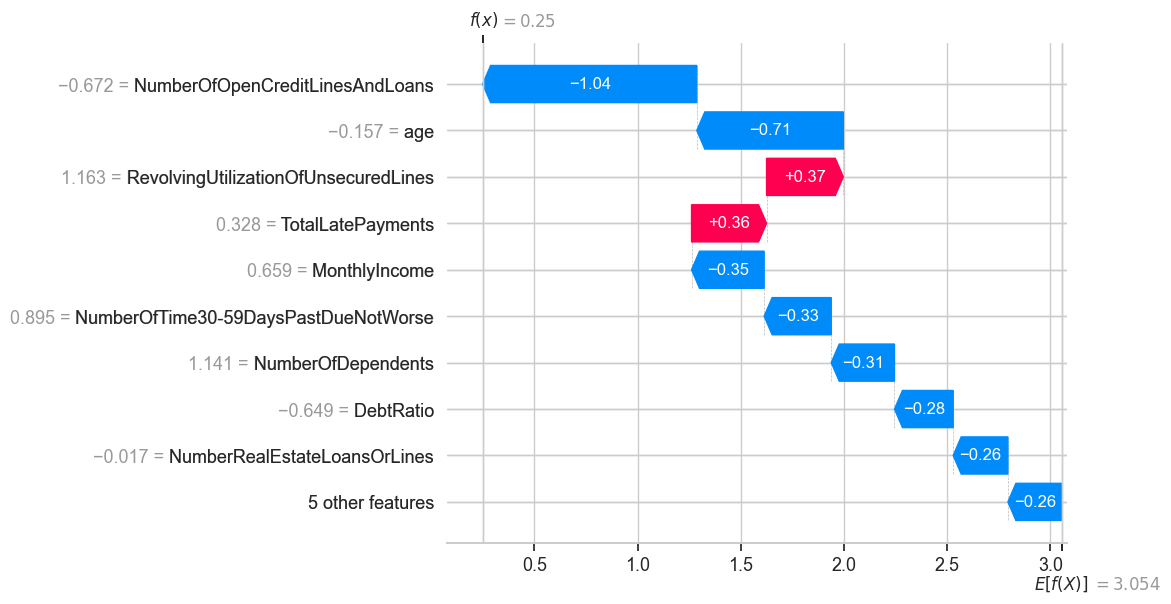


Waterfall plot for test observation 2


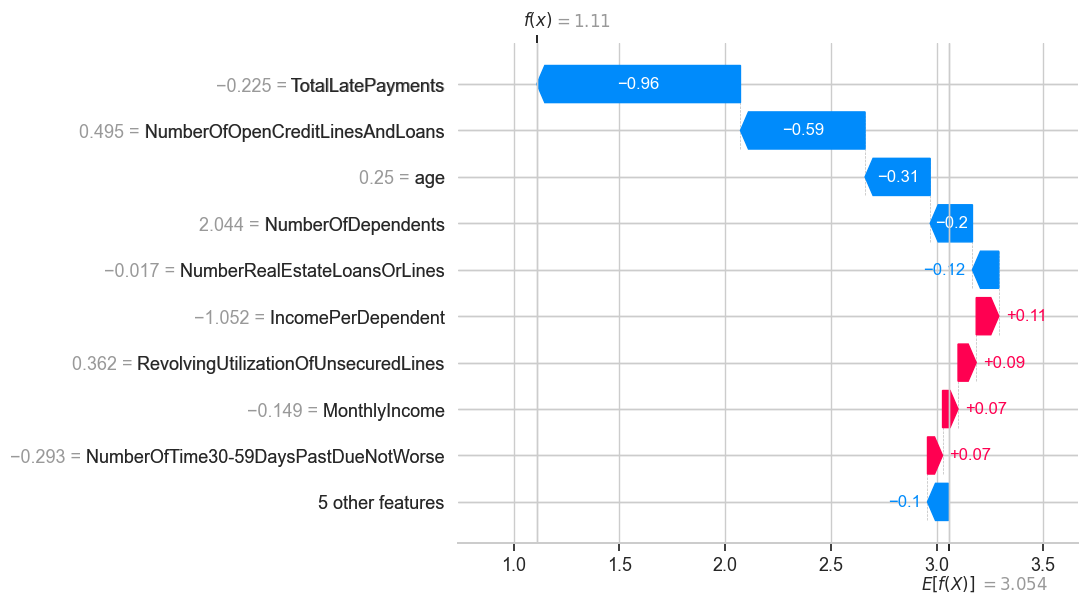


Top 5 most important features by mean absolute SHAP value:


,feature,mean_abs_shap
11,TotalLatePayments,1.192108
0,RevolvingUtilizationOfUnsecuredLines,0.980686
5,NumberOfOpenCreditLinesAndLoans,0.916577
1,age,0.581959
7,NumberRealEstateLoansOrLines,0.265009


In [10]:
# Create a SHAP TreeExplainer for the tuned XGBoost model.
explainer = shap.TreeExplainer(best_model)
shap_values = explainer(X_test_scaled)

# Plot global SHAP importance as a bar chart.
print('SHAP Summary Plot (Bar):')
shap.plots.bar(shap_values, max_display=15, show=True)

# Plot SHAP beeswarm/dot summary.
print('SHAP Summary Plot (Beeswarm):')
shap.plots.beeswarm(shap_values, max_display=15, show=True)

# Show SHAP waterfall plots for the first 3 test predictions.
for row_number in range(3):
    print(f'\nWaterfall plot for test observation {row_number}')
    shap.plots.waterfall(shap_values[row_number], show=True)

# Print top 5 features by mean absolute SHAP value.
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
shap_importance = pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap': mean_abs_shap,
}).sort_values('mean_abs_shap', ascending=False)
print('\nTop 5 most important features by mean absolute SHAP value:')
display(shap_importance.head(5))

## 11. SAVE MODEL

We save the tuned model, fitted scaler, and exact feature order. These artifacts let the FastAPI app score new applicants consistently.

In [11]:
# Save model and preprocessing artifacts.
joblib.dump(best_model, MODEL_PATH)
joblib.dump(scaler, SCALER_PATH)

# Save feature names in the exact training order.
FEATURE_NAMES_PATH.write_text('\n'.join(feature_names), encoding='utf-8')

print(f'Saved model to: {MODEL_PATH.resolve()}')
print(f'Saved scaler to: {SCALER_PATH.resolve()}')
print(f'Saved feature names to: {FEATURE_NAMES_PATH.resolve()}')

Saved model to: C:\Users\Ashish\OneDrive\Desktop\New folder\ml-project\credit_risk_model.pkl
Saved scaler to: C:\Users\Ashish\OneDrive\Desktop\New folder\ml-project\credit_scaler.pkl
Saved feature names to: C:\Users\Ashish\OneDrive\Desktop\New folder\ml-project\feature_names.txt


## 12. FASTAPI SCORING ENDPOINT

This cell writes a complete `app.py` file. The `/predict` endpoint accepts applicant feature values, recreates engineered features, scales them, predicts default probability, returns an approve/deny decision, and reports the top SHAP reason.

In [12]:
%%writefile app.py
# FastAPI scoring app for the Credit Risk Scoring ML project.
import warnings
from pathlib import Path
from typing import Any, Dict

import joblib
import numpy as np
import pandas as pd
import shap
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel, Field, ConfigDict

warnings.filterwarnings('ignore')

MODEL_PATH = Path('credit_risk_model.pkl')
SCALER_PATH = Path('credit_scaler.pkl')
FEATURE_NAMES_PATH = Path('feature_names.txt')
DECISION_THRESHOLD = 0.50

app = FastAPI(title='Credit Risk Scoring API', version='1.0.0')

class ApplicantFeatures(BaseModel):
    model_config = ConfigDict(populate_by_name=True)

    RevolvingUtilizationOfUnsecuredLines: float = Field(..., ge=0)
    age: float = Field(..., ge=18)
    NumberOfTime30_59DaysPastDueNotWorse: float = Field(..., alias='NumberOfTime30-59DaysPastDueNotWorse')
    DebtRatio: float
    MonthlyIncome: float
    NumberOfOpenCreditLinesAndLoans: float
    NumberOfTimes90DaysLate: float
    NumberRealEstateLoansOrLines: float
    NumberOfTime60_89DaysPastDueNotWorse: float = Field(..., alias='NumberOfTime60-89DaysPastDueNotWorse')
    NumberOfDependents: float

# Load artifacts at startup so predictions are fast.
def load_artifacts():
    if not MODEL_PATH.exists() or not SCALER_PATH.exists() or not FEATURE_NAMES_PATH.exists():
        raise RuntimeError('Required artifacts are missing. Run the notebook save step first.')
    model = joblib.load(MODEL_PATH)
    sc = joblib.load(SCALER_PATH)
    fnames = FEATURE_NAMES_PATH.read_text(encoding='utf-8').splitlines()
    exp = shap.TreeExplainer(model)
    return model, sc, fnames, exp

try:
    model, scaler, feature_names, explainer = load_artifacts()
    startup_error = None
except Exception as exc:
    model, scaler, feature_names, explainer = None, None, None, None
    startup_error = str(exc)

def build_model_frame(payload: Dict[str, Any]) -> pd.DataFrame:
    row = dict(payload)
    row['DebtToIncomeRatio'] = row['DebtRatio'] * row['MonthlyIncome']
    row['TotalLatePayments'] = (
        row['NumberOfTime30-59DaysPastDueNotWorse']
        + row['NumberOfTime60-89DaysPastDueNotWorse']
        + row['NumberOfTimes90DaysLate']
    )
    row['CreditUtilizationFlag'] = int(row['RevolvingUtilizationOfUnsecuredLines'] > 1)
    row['IncomePerDependent'] = row['MonthlyIncome'] / (row['NumberOfDependents'] + 1)
    missing = [f for f in feature_names if f not in row]
    if missing:
        raise HTTPException(status_code=400, detail=f'Missing features: {missing}')
    return pd.DataFrame([{f: row[f] for f in feature_names}])

@app.get('/health')
def health():
    return {'status': 'ok' if startup_error is None else 'artifact_error', 'detail': startup_error}

@app.post('/predict')
def predict(applicant: ApplicantFeatures):
    if startup_error is not None:
        raise HTTPException(status_code=500, detail=startup_error)
    payload = applicant.model_dump(by_alias=True)
    applicant_df = build_model_frame(payload)
    applicant_scaled = pd.DataFrame(scaler.transform(applicant_df), columns=feature_names)
    default_probability = float(model.predict_proba(applicant_scaled)[:, 1][0])
    decision = 'deny' if default_probability >= DECISION_THRESHOLD else 'approve'
    shap_vals = explainer.shap_values(applicant_scaled)
    sv = shap_vals[1] if isinstance(shap_vals, list) else shap_vals
    top_idx = int(np.argmax(np.abs(sv[0])))
    top_reason = feature_names[top_idx]
    return {
        'default_probability': round(default_probability, 4),
        'decision': decision,
        'top_reason': top_reason,
    }

Writing app.py


### How to Run the FastAPI App

After running the model-saving cell and the `%%writefile app.py` cell, start the API from a terminal in this notebook's folder:

```bash
uvicorn app:app --reload
```

Then open `http://127.0.0.1:8000/docs` to test the `/predict` endpoint interactively.

**Example request body:**
```json
{
  "RevolvingUtilizationOfUnsecuredLines": 0.5,
  "age": 45,
  "NumberOfTime30-59DaysPastDueNotWorse": 0,
  "DebtRatio": 0.3,
  "MonthlyIncome": 8000,
  "NumberOfOpenCreditLinesAndLoans": 8,
  "NumberOfTimes90DaysLate": 0,
  "NumberRealEstateLoansOrLines": 1,
  "NumberOfTime60-89DaysPastDueNotWorse": 0,
  "NumberOfDependents": 2
}
```

## 13. Bonus: Alternative Dataset Exploration (Lending Club)

This section loads and explores an alternative, much larger dataset from Lending Club (`ranadeep/credit-risk-dataset`). This dataset contains 887,379 loans with 74 features, compared to the 11 features in the original `cs-training.csv` dataset. Because the features and definitions of default are different, they require separate modeling pipelines.

In [13]:
import pandas as pd

print("Loading Lending Club dataset from local file...")
file_path = "loan.csv"

# Load the dataset directly into a pandas DataFrame
df_lc = pd.read_csv(file_path, low_memory=False)

print(f"\nDataset Shape: {df_lc.shape}")
print("\nFirst 5 records:")
display(df_lc.head())

# Show a breakdown of the loan_status column which can be used to define 'Default'
print("\nLoan Status Breakdown:")
display(df_lc['loan_status'].value_counts(dropna=False).to_frame('Count'))

Loading Lending Club dataset from local file...



Dataset Shape: (887379, 74)

First 5 records:


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,1077501,1296599,5000.0,5000.0,4975.0,36 months,10.65,162.87,B,B2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1077430,1314167,2500.0,2500.0,2500.0,60 months,15.27,59.83,C,C4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1077175,1313524,2400.0,2400.0,2400.0,36 months,15.96,84.33,C,C5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1076863,1277178,10000.0,10000.0,10000.0,36 months,13.49,339.31,C,C1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1075358,1311748,3000.0,3000.0,3000.0,60 months,12.69,67.79,B,B5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Loan Status Breakdown:


,Count
loan_status,
Current,601779
Fully Paid,207723
Charged Off,45248
Late (31-120 days),11591
Issued,8460
In Grace Period,6253
Late (16-30 days),2357
Does not meet the credit policy. Status:Fully Paid,1988
Default,1219
